In [1]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load the dataset
data=pd.read_csv("spamdata.csv")

# display data
print(data.head())
print("-"*50)
print(data.tail())


   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
--------------------------------------------------
      label                                               text
5567      1  This is the 2nd time we have tried 2 contact u...
5568      0              Will Ì_ b going to esplanade fr home?
5569      0  Pity, * was in mood for that. So...any other s...
5570      0  The guy did some bitching but I acted like i'd...
5571      0                         Rofl. Its true to its name


In [3]:
# data shape
print("data shape:", data.shape)

data shape: (5572, 2)


In [4]:
# data types
print(data.dtypes)

label    int64
text       str
dtype: object


In [5]:
# data info
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   int64
 1   text    5572 non-null   str  
dtypes: int64(1), str(1)
memory usage: 524.4 KB
None


In [6]:
# descriptive statistics
print(data.describe())

             label
count  5572.000000
mean      0.134063
std       0.340751
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000


In [7]:
print("Null values in each column:",data.isnull().sum())
print("Empty strings in each column:",data["text"].fillna("").str.strip().eq("").sum())
print("Duplicated rows:",data.duplicated().sum())

Null values in each column: label    0
text     0
dtype: int64
Empty strings in each column: 0
Duplicated rows: 403


In [8]:
# need to remove duplicates
print("before removing duplicates:",len(data))
data = data.drop_duplicates().reset_index(drop=True)
print("after removing duplicates:",len(data))

before removing duplicates: 5572
after removing duplicates: 5169


In [9]:
# class imbalance check
print("Class distribution:\n",data["label"].value_counts())
print("Class distribution percentage:\n",data["label"].value_counts(normalize=True)*100)

Class distribution:
 label
0    4516
1     653
Name: count, dtype: int64
Class distribution percentage:
 label
0    87.366996
1    12.633004
Name: proportion, dtype: float64


In [10]:
X=data["text"]
y=data["label"]

print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (5169,)
y shape: (5169,)


In [11]:
# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 3876
Testing samples: 1293


In [12]:
# vectorization using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nX_train TF-IDF shape:", X_train_tfidf.shape)
print("X_test TF-IDF shape:", X_test_tfidf.shape)


X_train TF-IDF shape: (3876, 5000)
X_test TF-IDF shape: (1293, 5000)


In [13]:
# class imbalance handling
negative=(y_train==0).sum()
positive=(y_train==1).sum()

scale_pos_weight=negative/positive

print("\nClass imbalance:")
print("Not Spam:", negative)
print("Spam:", positive)
print("scale_pos_weight:",scale_pos_weight)



Class imbalance:
Not Spam: 3386
Spam: 490
scale_pos_weight: 6.910204081632653


In [14]:
model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


In [15]:
model.fit(
    X_train_tfidf,
    y_train,
    eval_set=[(X_train_tfidf, y_train), (X_test_tfidf, y_test)],
    verbose=True
)

print("\nModel training completed.")

[0]	validation_0-logloss:0.67215	validation_1-logloss:0.67148
[1]	validation_0-logloss:0.64677	validation_1-logloss:0.64520
[2]	validation_0-logloss:0.63060	validation_1-logloss:0.62899
[3]	validation_0-logloss:0.60735	validation_1-logloss:0.60592
[4]	validation_0-logloss:0.58594	validation_1-logloss:0.58456
[5]	validation_0-logloss:0.56547	validation_1-logloss:0.56437
[6]	validation_0-logloss:0.54645	validation_1-logloss:0.54515
[7]	validation_0-logloss:0.52914	validation_1-logloss:0.52784
[8]	validation_0-logloss:0.51350	validation_1-logloss:0.51283
[9]	validation_0-logloss:0.49961	validation_1-logloss:0.49905
[10]	validation_0-logloss:0.48524	validation_1-logloss:0.48467
[11]	validation_0-logloss:0.47425	validation_1-logloss:0.47410
[12]	validation_0-logloss:0.46159	validation_1-logloss:0.46143
[13]	validation_0-logloss:0.45049	validation_1-logloss:0.45064
[14]	validation_0-logloss:0.43835	validation_1-logloss:0.43866
[15]	validation_0-logloss:0.42749	validation_1-logloss:0.42800
[1

In [16]:
y_pred = model.predict(X_test_tfidf)

# Probability of SPAM
y_prob = model.predict_proba(X_test_tfidf)[:, 1]


print("\nFirst 20 predictions:")
print(y_pred[:20])

print("\nFirst 20 spam probabilities:")
print(y_prob[:20])


First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 spam probabilities:
[0.35210538 0.01290015 0.03658039 0.20173955 0.04650851 0.00336546
 0.02316978 0.04650851 0.03082416 0.06790999 0.02757265 0.02252105
 0.03729371 0.06416436 0.15093087 0.05385229 0.22643657 0.04503443
 0.01077672 0.05068125]


In [17]:
# evaluation metrics
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred,zero_division=0)
recall = recall_score(y_test,y_pred,zero_division=0)
f1 = f1_score(y_test,y_pred,zero_division=0)
roc_auc = roc_auc_score(y_test,y_prob)


In [18]:
print("XGBOOST SPAM CLASSIFICATION RESULTS")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

XGBOOST SPAM CLASSIFICATION RESULTS
Accuracy : 0.9745
Precision: 0.9333
Recall   : 0.8589
F1 Score : 0.8946
ROC-AUC  : 0.9778


In [19]:
print("\nClassification Report:")
print(classification_report(y_test,y_pred,target_names=["NOT SPAM","SPAM"],zero_division=0))


Classification Report:
              precision    recall  f1-score   support

    NOT SPAM       0.98      0.99      0.99      1130
        SPAM       0.93      0.86      0.89       163

    accuracy                           0.97      1293
   macro avg       0.96      0.93      0.94      1293
weighted avg       0.97      0.97      0.97      1293



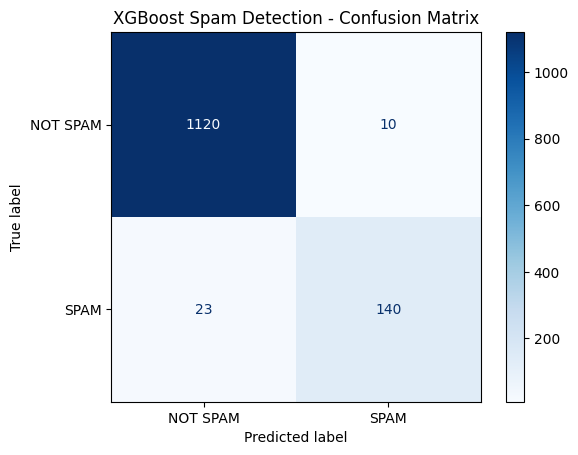

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=["NOT SPAM","SPAM"],cmap="Blues")
plt.title("XGBoost Spam Detection - Confusion Matrix")
plt.show()

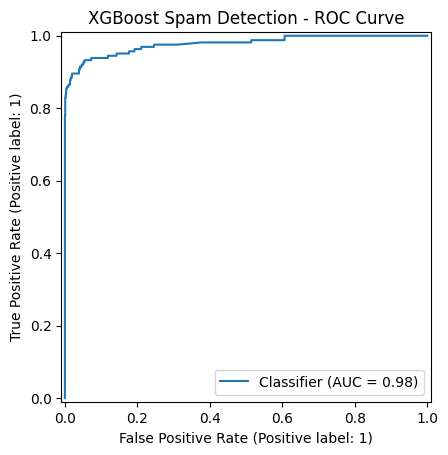

In [21]:
RocCurveDisplay.from_predictions(y_test,y_prob)
plt.title("XGBoost Spam Detection - ROC Curve")
plt.show()

In [22]:
test_messages = [
    "Congratulations! You have won a $1000 cash prize. Call now to claim.",
    "Hey, are we still meeting for lunch today?",
    "URGENT! Your account has been selected for a free reward. Click the link now.",
    "Can you send me the project report before 5 PM?",
    "You have won a free iPhone! Claim your prize by sending your details.",
    "Hi, I will be late today because of traffic.",
    "FREE entry! Text WIN to 80082 to receive your guaranteed cash prize.",
    "Please remember to bring your laptop to the meeting tomorrow.",
    "Your mobile number has won a special bonus. Call now to receive your reward.",
    "Hey, are you coming to the party tonight?"
]

In [23]:
test_tfidf = vectorizer.transform(test_messages)
predictions = model.predict(test_tfidf)
probabilities = model.predict_proba(test_tfidf)[:, 1]

# Display results
for i, (message, prediction, probability) in enumerate(zip(test_messages, predictions, probabilities), 1):
    result = "SPAM" if prediction == 1 else "NOT SPAM"
    print(f"{i}. {result}")
    print(f"Message: {message}")
    print(f"Spam probability: {probability:.2%}")
    print()

1. SPAM
Message: Congratulations! You have won a $1000 cash prize. Call now to claim.
Spam probability: 98.63%

2. NOT SPAM
Message: Hey, are we still meeting for lunch today?
Spam probability: 5.62%

3. SPAM
Message: URGENT! Your account has been selected for a free reward. Click the link now.
Spam probability: 89.10%

4. NOT SPAM
Message: Can you send me the project report before 5 PM?
Spam probability: 1.27%

5. SPAM
Message: You have won a free iPhone! Claim your prize by sending your details.
Spam probability: 86.32%

6. NOT SPAM
Message: Hi, I will be late today because of traffic.
Spam probability: 5.72%

7. SPAM
Message: FREE entry! Text WIN to 80082 to receive your guaranteed cash prize.
Spam probability: 97.56%

8. NOT SPAM
Message: Please remember to bring your laptop to the meeting tomorrow.
Spam probability: 18.12%

9. SPAM
Message: Your mobile number has won a special bonus. Call now to receive your reward.
Spam probability: 95.69%

10. NOT SPAM
Message: Hey, are you comi

In [24]:
def check_spam(message):
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)[0]
    probability = model.predict_proba(message_tfidf)[0, 1]
    result = "SPAM" if prediction == 1 else "NOT SPAM"

    return result, probability

In [25]:
message = (
    "Congratulations! You have won a free "
    "iPhone. Call now to claim your prize!"
)

result, probability = check_spam(message)

print("\n"+"="*50)
print("SINGLE MESSAGE TEST")
print("="*50)
print("Message:", message)
print("Result:", result)
print(f"Spam probability: {probability:.2%}")


SINGLE MESSAGE TEST
Message: Congratulations! You have won a free iPhone. Call now to claim your prize!
Result: SPAM
Spam probability: 99.45%
